# Example of the aitlas toolbox in the context of change detection

## Define the FAIREOSchema for dataset import

In [2]:
from marshmallow import fields

from aitlas.base.schemas import BaseDatasetSchema


class FAIREOSchema(BaseDatasetSchema):
    """
    Schema for configuring FAIR-EO datasets.
    """
    csv_file = fields.String(
        load_default=None, metadata={"description": "CSV file on disk", "example": "./data/train.csv"}
    )
    data_dir = fields.String(
        load_default="/", metadata={"description": "Dataset path on disk", "example": "./data/CESBIO/"}
    )
    selection = fields.String(
        load_default="rgb", metadata={"description": "Read RGB channels or more than 3 channels", "example": "all/rgb"}
    )
    mode = fields.String(
        load_default=None, metadata={"description": "train/val or test task", "example": "train"}
    )


## Define the California Flood dataset
The dataset consists of three images (time1, time2, ground truth) which are resampled, co-registered 
and cropped to cover an area affected by a flood.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import scipy.io

from aitlas.datasets.semantic_segmentation import BaseDataset
from aitlas.utils import image_loader


PATCH_H, PATCH_W = 256, 256

class CaliforniaFloodDataset(BaseDataset):

    url = "https://sites.google.com/view/luppino/data"
    name = "California Flood"
    schema = FAIREOSchema
    labels = ["no change","change"]
    color_mapping =  [[0,0,0],[255,255,255]]


    def __init__(self, config):
        # now call the constructor to validate the schema and split the data
        super().__init__(config)
        self.data_dir = self.config.data_dir
        self.mode = self.config.mode
        self.selection = self.config.selection
        self.data, self.masks = self.load_dataset(self.data_dir)

    def __getitem__(self, index):
        if self.selection == 'rgb':
            pre_image = self.data[index][0][:,:,:3]
            post_image = self.data[index][1][:,:,:3]
        elif self.selection == 'all':
            pre_image = self.data[index][0]
            post_image = self.data[index][1]

        # normalize images for better visualization
        pre_img_min, pre_img_max = pre_image.min(), pre_image.max()
        pre_image = (pre_image - pre_img_min) / (pre_img_max - pre_img_min + 1e-8)

        post_img_min, post_img_max = post_image.min(), post_image.max()
        post_image = (post_image - post_img_min) / (post_img_max - post_img_min + 1e-8)

        mask = self.masks[index]
        masks = [(mask == v) for v, label in enumerate(self.labels)]
        mask = np.stack(masks, axis=-1).astype("float32")

        if self.transform:
            pre_image = self.transform(pre_image)
            post_image = self.transform(post_image)
        if self.target_transform:
            mask = self.target_transform(mask)
        
        return (pre_image, post_image), mask


    def load_dataset(self, data_dir):
        self.data = []
        self.masks = []
        mat_data = scipy.io.loadmat(data_dir)
        im1 = mat_data['t1_L8_clipped']
        im2 = mat_data['logt2_clipped']
        mask = mat_data['ROI']

        if self.mode == None: # consider the original image
            self.data.append((im1, im2))
            self.masks.append(mask)
        
        elif self.mode: # create patches of the original image to increase the amount of training data
            stride = PATCH_H
            # (height, width, bands) format
            img_h, img_w = im1.shape[:2]
            for y in range(0, img_h - PATCH_H + 1, stride):
                for x in range(0, img_w - PATCH_W + 1, stride):
                    if y + PATCH_H <= img_h and x + PATCH_W <= img_w:
                        self.data.append((im1[y:y+PATCH_H, x:x+PATCH_W], im2[y:y+PATCH_H, x:x+PATCH_W]))
                        self.masks.append(mask[y:y+PATCH_H, x:x+PATCH_W])

            train = round((len(self.data)/100)*80)
            val = round((len(self.data)/100)*10)

            if self.mode == "train":
                self.data = self.data[: train]
            elif self.mode == "val":
                self.data = self.data[train : (train+val)]
            elif self.mode == "test":
                self.data = self.data[train+val :]

        return self.data, self.masks

    def __len__(self):
        return len(self.data)
    
    def get_labels(self):
        return self.labels

    def show_image(self, index, show_title=False):
        data = self[index]
        (pre_img, post_img), mask = data

        # Create mask visualization
        img_mask = np.zeros([mask.shape[0], mask.shape[1], 3], np.uint8)
        legend_elements = []
        for i, label in enumerate(self.labels):
            legend_elements.append(
                Patch(
                    facecolor=tuple([x / 255 for x in self.color_mapping[i]]),
                    label=self.labels[i],
                )
            )
            img_mask[np.where(mask[:, :, i] == 1)] = self.color_mapping[i]

        fig = plt.figure(figsize=(15, 6))

        # Create subplot with space for legend on top
        plt.subplots_adjust(top=0.85, bottom=0.1)

        # Add legend at the top
        fig.legend(handles=legend_elements, bbox_to_anchor=(0.1, 1.05, 0.8, 0.05), ncol=3,
                    loc='center', prop={'size': 12})

        plt.subplot(1, 3, 1)
        plt.imshow(pre_img)
        plt.title("Pre-event")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(post_img)
        plt.title("Post-event")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(img_mask)
        plt.title("Mask")
        plt.axis("off")

        fig.tight_layout()
        plt.show()
        return fig


    def data_distribution_table(self):
        label_dist = {key: 0 for key in self.labels}
        for i in np.arange(len(self.data)):
            image, mask = self.__getitem__(i)
            for index, label in enumerate(self.labels):
                label_dist[self.labels[index]] += mask[:, :, index].sum()
        label_count = pd.DataFrame.from_dict(label_dist, orient='index')
        label_count.columns = ["Number of pixels"]
        return label_count

    def data_distribution_barchart(self, show_title=True):
        label_count = self.data_distribution_table()
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.barplot(data=label_count, x=label_count.index, y='Number of pixels', ax=ax)
        if show_title:
            ax.set_title(
                "Labels distribution for {}".format(self.get_name()), pad=20, fontsize=18
            )
        return fig

## Visualize images and masks

Original image

In [4]:
dataset_config = {
    "data_dir" : "/home/dragik/data/FAIR_EO/california_flood/UiT_HCD_California_2017.mat",
    "selection": "rgb"
}
dataset = CaliforniaFloodDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")

Total number of patches: 1


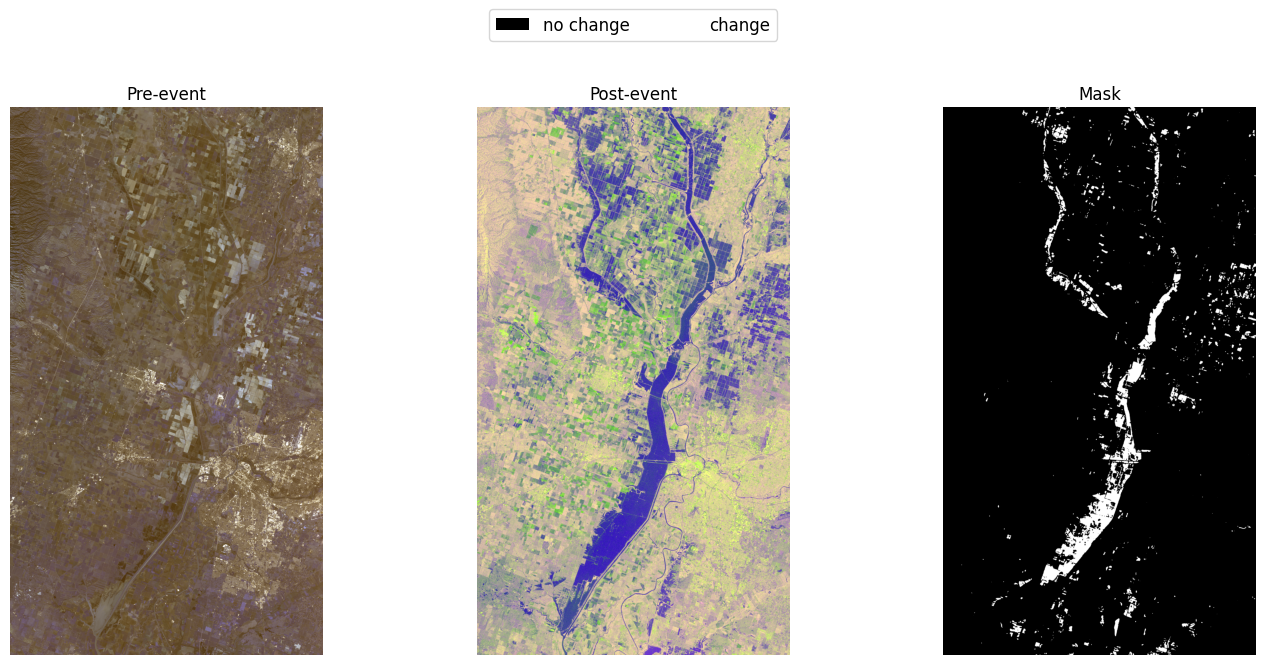

In [5]:
dataset.show_image(0);

In [11]:
dataset.data_distribution_table()

,Number of pixels
no change,6694073.0
change,305927.0


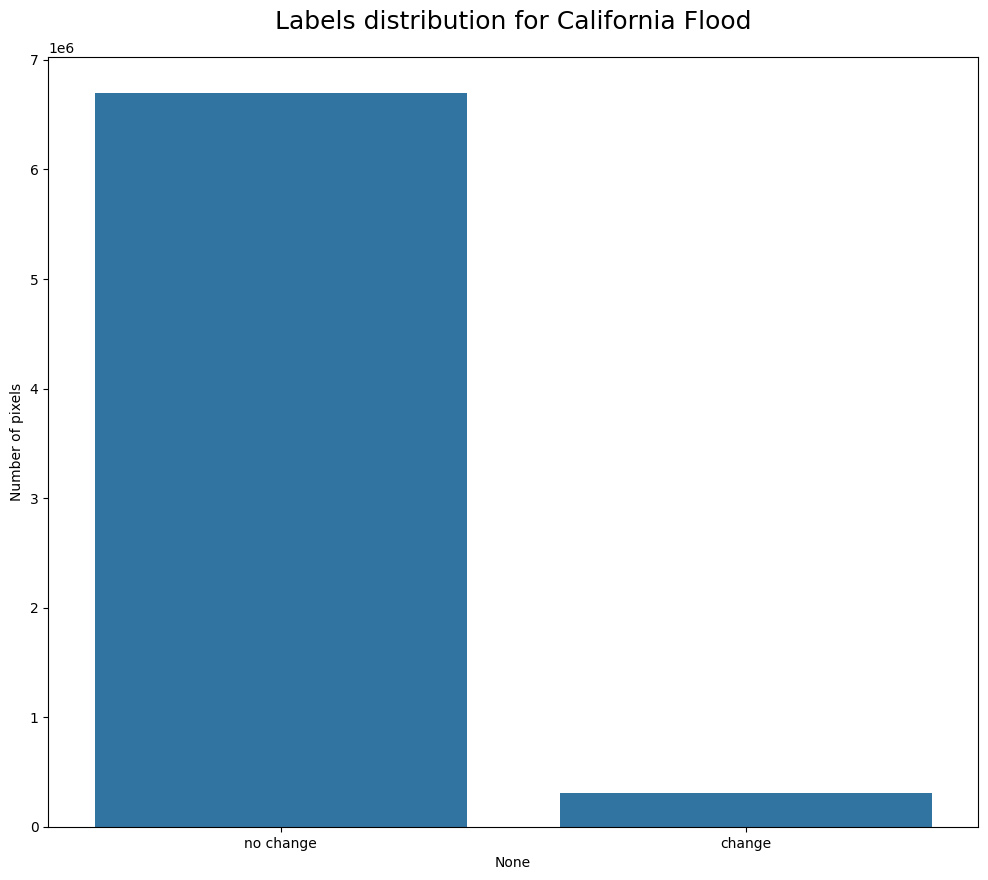

In [12]:
dataset.data_distribution_barchart();

Patches of the original image

Total number of patches: 73


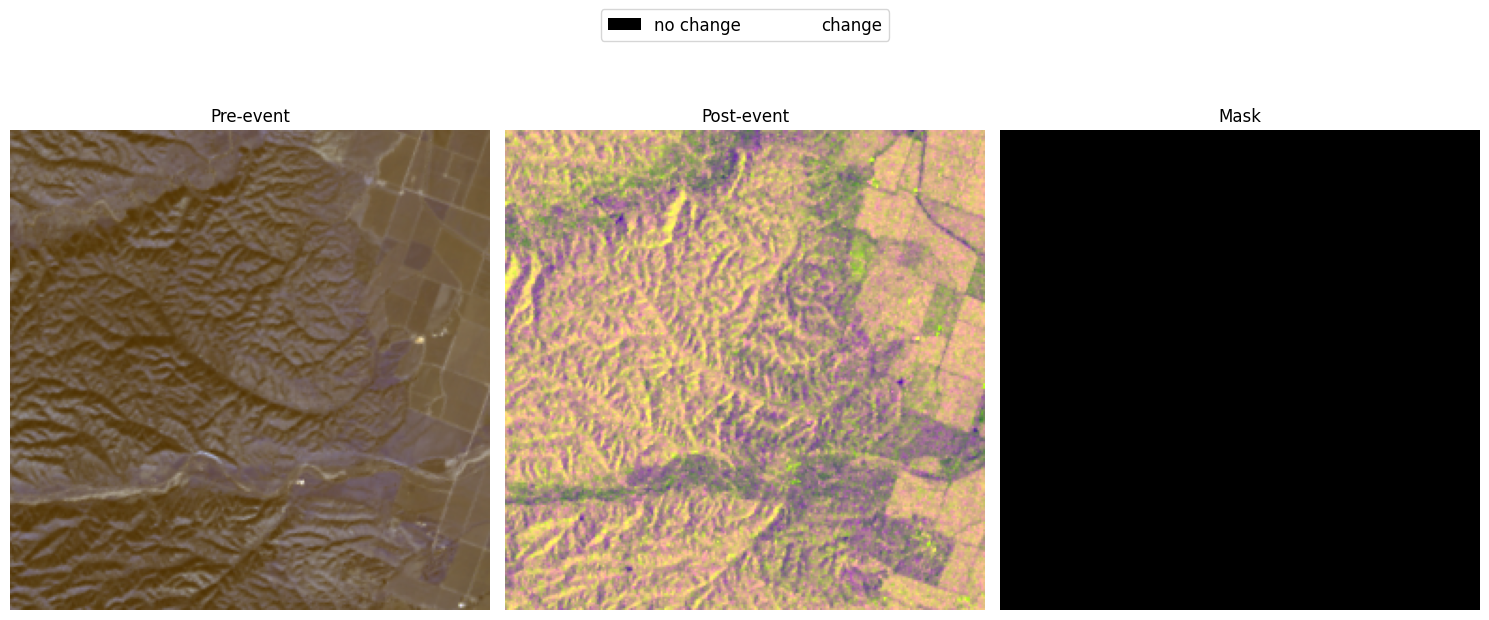

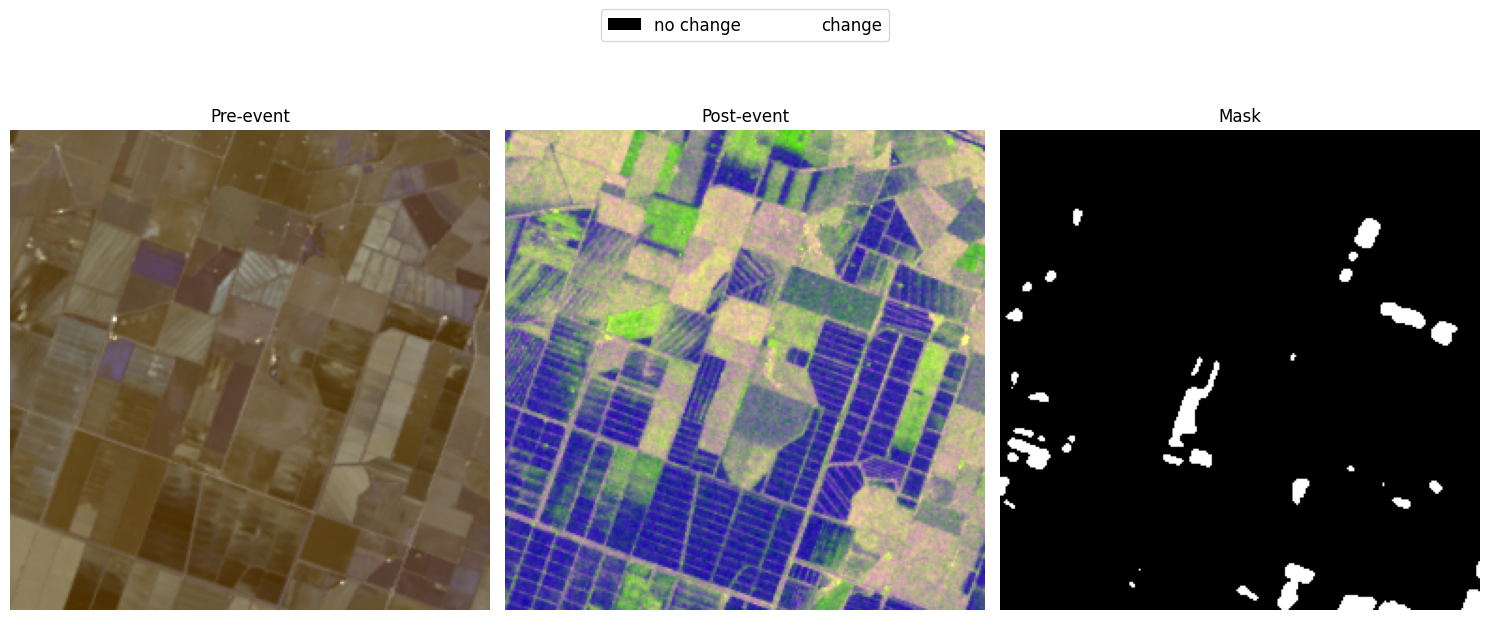

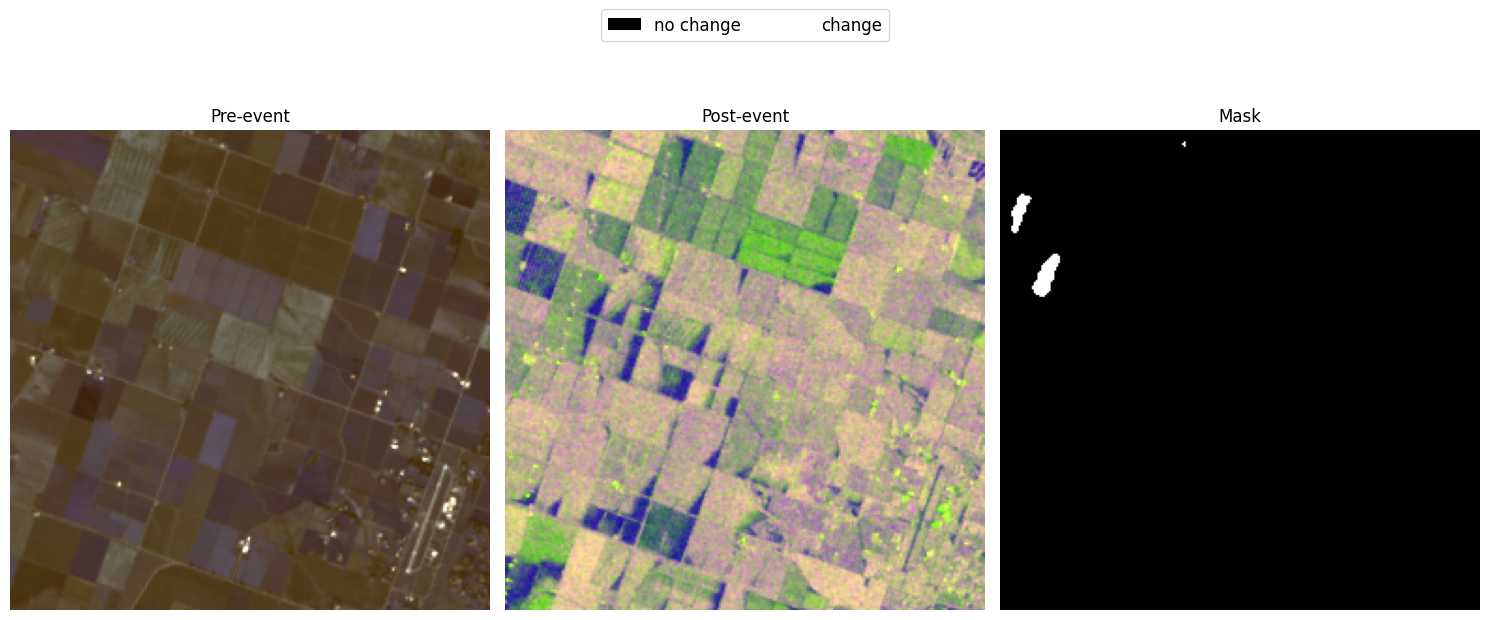

In [6]:
dataset_config = {
    "data_dir" : "/home/dragik/data/FAIR_EO/california_flood/UiT_HCD_California_2017.mat",
    "selection": "rgb",
    "mode": "train"
}
dataset = CaliforniaFloodDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")

dataset.show_image(0);
dataset.show_image(10);
dataset.show_image(50);

## Load training and test data

In [14]:
train_dataset_config = {
    "batch_size": 8,
    "shuffle": True,
    "num_workers": 4,
    "data_dir" : "/home/dragik/data/FAIR_EO/california_flood/UiT_HCD_California_2017.mat",
    "selection": "rgb",
    "mode": "train",
    "transforms": ["aitlas.transforms.MinMaxNormTranspose","aitlas.transforms.ResizeToTensor"],
    "target_transforms": ["aitlas.transforms.Transpose","aitlas.transforms.ResizePerChannelToTensor"]
}
train_dataset = CaliforniaFloodDataset(train_dataset_config)

test_dataset_config = {
    "batch_size": 8,
    "shuffle": True,
    "num_workers": 4,
    "data_dir" : "/home/dragik/data/FAIR_EO/california_flood/UiT_HCD_California_2017.mat",
    "selection": "rgb",
    "mode": "val",
    "transforms": ["aitlas.transforms.MinMaxNormTranspose","aitlas.transforms.ResizeToTensor"],
    "target_transforms": ["aitlas.transforms.Transpose","aitlas.transforms.ResizePerChannelToTensor"]
}
test_dataset = CaliforniaFloodDataset(test_dataset_config)
len(train_dataset), len(test_dataset)

(73, 9)

## Create the model

In [15]:
from aitlas.models import UnetChangeDetection

epochs = 50
model_directory = "/home/dragik/data/FAIR_EO/experiments/california_flood"
model_config = {
    "num_classes": 2, 
    "learning_rate": 0.0001,
    "pretrained": False, 
    "threshold": 0.5,
    "metrics": ["accuracy", "precision", "recall", "f1_score", "iou"]
}

model = UnetChangeDetection(model_config)
model.prepare()

## Start the training

In [16]:
model.train_and_evaluate_model(
    train_dataset=train_dataset,
    epochs=epochs,
    model_directory=model_directory,
    run_id='1',
)

model_path = model_directory + "/checkpoint.pth.tar"
model.load_model(model_path)
model.running_metrics.reset()
model.evaluate(dataset=test_dataset, model_path=model_path)
test_metrics = model.running_metrics.get_scores(model.metrics)

2026-05-06 13:23:22,106 INFO Starting training.
training: 100%|██████████| 10/10 [00:01<00:00,  8.33it/s]
2026-05-06 13:23:23,344 INFO epoch: 1, loss:  0.32152
testing on train set: 100%|██████████| 10/10 [00:00<00:00, 13.78it/s]
2026-05-06 13:23:25,504 INFO Accuracy:0.039813316031678085, Accuracy per Class:[0.03981332 0.03981332], Precision Micro:0.039813316031678085, Precision Macro:0.019906658015839043, Precision Weighted:0.0015851001334382753, Precision per Class:[0.         0.03981332], Recall Micro:0.039813316031678085, Recall Macro:0.5, Recall Weighted:0.039813316031678085, Recall per Class:[0. 1.], F1_score Micro:0.039813316031677586, F1_score Macro:0.038288907650866365, F1_score Weighted:0.003048816761623359, F1_score per Class:[0.         0.07657782], IOU:0.020310981784182704, IOU mean:0.019906658015839043, IOU per Class:[0.         0.03981332]
training: 100%|██████████| 10/10 [00:01<00:00,  8.80it/s]
2026-05-06 13:23:26,645 INFO epoch: 2, loss:  0.29515
testing on train set:

## Predictions

In [ ]:
from aitlas.transforms import ResizeToTensor

model_path = "/home/dragik/data/FAIR_EO/experiments/california_flood/checkpoint.pth.tar"
labels = ["no change","change"]
transform = ResizeToTensor()
model.load_model(model_path)

test_dataset_config = {
    "data_dir" : "/home/dragik/data/FAIR_EO/california_flood/UiT_HCD_California_2017.mat",
    "selection": "rgb",
    "mode": "test"
}
test_dataset = CaliforniaFloodDataset(test_dataset_config)
print(len(test_dataset))

image1 = test_dataset[0][0][0]
image2 = test_dataset[0][0][1]
fig = model.predict_masks(image1, image2, labels, transform)

image1 = test_dataset[5][0][0]
image2 = test_dataset[5][0][1]
fig = model.predict_masks(image1, image2, labels, transform)

NameError: name 'ResizeToTensor' is not defined